# 🚚⚠️📊 Прогнозирование риска задержки доставки CargaPronto: сегментация клиентов и бинарная классификация заказов

Автор: Якунин Михаил

Дата: "__" _______ 2026 г.

***По этой ссылке можно посмотреть проект и скачать последнюю версию: https://github.com/MEYakunin/Sprint18_Delivery_Delay_Prediction.git***

## Цель проекта

*Цель проекта* — построить для логистической компании CargaPronto модель бинарной классификации, которая по данным о заказе и профиле клиента будет предсказывать риск задержки доставки (`late_delivery_risk`) ещё в момент оформления заказа. 

*Конечный продукт* — система поддержки принятия решений для диспетчеров: при высоком риске опоздания (>70%) система должна выдавать предупреждение и рекомендовать сменить приоритет доставки, что позволит компании активно управлять ситуацией вместо того, чтобы констатировать факт нарушения SLA.

*Ключевая задача исследования* — проверить гипотезу транспортного департамента о «неоднородности» клиентской базы: подтвердить, что риск задержки определяется не только параметрами самого заказа, но и географическим положением клиента, а также его поведенческим профилем (частота заказов, сумма покупок, доля возвратов, чувствительность к скидкам). Для этого клиенты будут сегментированы с помощью кластеризации K-Means++ на логистические зоны (`geo_cluster`) и поведенческие сегменты (`beh_cluster`), после чего полученные признаки добавляются в обучающие данные моделей.

*Целевой показатель качества* — ROC-AUC > 0.75 на тестовой выборке: метрика оценивает способность модели ранжировать заказы по степени риска, что позволит диспетчерам точечно выделять доставки, требующие повышенного внимания.

## Задача проекта

*Задача проекта* — разработать модель бинарной классификации, которая в момент оформления заказа предсказывает целевую переменную `late_delivery_risk`: 1 — заказ доставлен с задержкой, 0 — доставлен вовремя. Входными данными служат параметры самого заказа (`order_id`, `customer_id`, `order_date`, `shipping_mode`, `category_name`, `item_price`) и профиль клиента из справочника (`customer_lat`, `customer_lon`, `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`).

*Инструменты моделирования* — логистическая регрессия (быстрая и прозрачная, задаёт «нижнюю планку» качества) и `CatBoostClassifier` (градиентный бустинг, способный находить сложные закономерности). Метрика качества — `ROC-AUC`: она оценивает способность модели ранжировать заказы по степени риска, что позволяет диспетчерам точечно выделять доставки, требующие повышенного внимания. Удовлетворительный результат — `ROC-AUC` > 0.75 на тестовой выборке.

*План работы:*
1. Загрузка датасетов `ds_s18_customers.csv` и `ds_s18_orders.csv`, технический аудит, устранение полных дубликатов, проверка целостности данных, подготовка временных признаков `order_month`, `order_weekday`, `order_hour`.
2. EDA: проверка баланса классов, географический аудит и удаление аномалий координат, анализ зависимостей признаков.
3. Разделение заказов на обучающую, валидационную и тестовую выборки в соотношении 60:20:20 с помощью `GroupShuffleSplit` (клиенты не должны пересекаться между выборками).
4. Обучение базовых моделей (логистическая регрессия и `CatBoostClassifier`) на признаках заказа — фиксация точки отсчёта качества.
5. Кластеризация клиентов: геокластеры (`geo_cluster`) по координатам и поведенческие сегменты (`beh_cluster`) по RFM-признакам, с выбором числа кластеров методом локтя и защитой от утечки данных.
6. Обучение финальных моделей на расширенном наборе признаков и оценка ROC-AUC на валидационной выборке.
7. Тестирование лучшей модели на тестовой выборке: итоговый ROC-AUC, матрица ошибок, анализ важности признаков.
8. Выводы и бизнес-рекомендации для CargaPronto.

## Описание данных

В проекте используются два датасета, выгруженные из ERP-системы компании CargaPronto.

1. `ds_s18_customers.csv` — профили уникальных клиентов

Справочник содержит агрегированную информацию о каждом клиенте: географическое положение и поведенческие показатели, собранные по методу RFM.

| Признак | Описание |
| :--- | :--- |
| `customer_id` | Уникальный номер клиента в системе ERP; ключ для связи с таблицей заказов |
| `customer_lat` | Широта местонахождения клиента |
| `customer_lon` | Долгота местонахождения клиента |
| `recency` | Количество дней, прошедших с момента последнего заказа до точки отсчёта (Recency) |
| `total_orders` | Общее количество совершённых заказов (Frequency) |
| `total_sales` | Суммарная выручка, которую клиент принёс компании за всё время (Monetary) |
| `avg_discount` | Средний размер скидки, которую получает клиент; маркер чувствительности к акциям |
| `return_rate` | Доля проблемных заказов (возвраты и отмены); ключевой показатель нагрузки на курьеров |

2. `ds_s18_orders.csv` — заказы клиентов

Таблица событий, где зафиксирован каждый факт продажи и итог доставки; здесь находится целевая переменная.

| Признак | Описание |
| :--- | :--- |
| `order_id` | Уникальный номер заказа |
| `customer_id` | Идентификатор клиента; ключ для связи с профилем из справочника |
| `order_date` | Дата и время совершения покупки |
| `category_name` | Категория заказанного товара |
| `item_price` | Стоимость товара в заказе |
| `shipping_mode` | Режим доставки: Standard Class, First Class, Second Class, Same Day |
| `late_delivery_risk` | Целевая переменная: 1 — заказ доставлен с задержкой; 0 — заказ доставлен вовремя |

## Содержание <a id="content"></a>

* [1. Импорт библиотек, выполнение базовых настроек](#1)
* [2. Загрузка данных, первичное знакомство](#2)
  * [2.1. Технический аудит данных](#2_1)
  * [2.2. Устранение дубликатов и проверка целостности (ID-Check)](#2_2)
  * [2.3. Подготовка признаков даты и времени](#2_3)
  * [2.4. Промежуточный итог](#2_4)
* [3. EDA](#3)
  * [3.1. Проверка баланса классов](#3_1)
  * [3.2. Географический аудит](#3_2)
  * [3.3. Удаление аномалий](#3_3)
  * [3.4. Анализ зависимостей между признаками](#3_4)
* [4. Разделение на выборки](#4)
* [5. Обучение базовой модели](#5)
  * [5.1. Логистическая регрессия](#5_1)
  * [5.2. CatBoostClassifier](#5_2)
  * [5.3. Оценка качества на валидационной выборке](#5_3)
* [6. Кластеризация по признакам, связанным с местоположением](#6)
  * [6.1. Подготовка признаков и защита от утечки данных](#6_1)
  * [6.2. Выбор числа кластеров методом локтя](#6_2)
  * [6.3. Визуализация кластеров и центроидов](#6_3)
* [7. Кластеризация по признакам профилей клиентов](#7)
  * [7.1. Подготовка векторов признаков и предобработка](#7_1)
  * [7.2. Выбор числа кластеров методом локтя](#7_2)
  * [7.3. Анализ полученных сегментов](#7_3)
  * [7.4. Визуализация кластеров с помощью t-SNE](#7_4)
* [8. Обучение модели на новых признаках](#8)
  * [8.1. Добавление `geo_cluster` и `beh_cluster` в данные](#8_1)
  * [8.2. Обучение финальных моделей](#8_2)
  * [8.3. Оценка ROC-AUC на валидационной выборке](#8_3)
* [9. Дополнительное задание — подбор лучшего количества кластеров](#9)
* [10. Тестирование лучшей модели](#10)
  * [10.1. Предсказание на тестовой выборке и итоговый ROC-AUC](#10_1)
  * [10.2. Матрица ошибок](#10_2)
  * [10.3. Анализ важности признаков](#10_3)
* [11. Выводы и рекомендации](#11)

## [1. Импорт библиотек, выполнение базовых настроек](#content)<a id="1"></a>

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [1]:
#%pip install -r requirements.txt

In [2]:
# Стандартные библиотеки

# Сторонние библиотеки
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from catboost import CatBoostClassifier
from optuna.pruners import MedianPruner

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

d:\ProjectPython\Sprint18_Delivery_Delay_Prediction\.ml_env_sprint18\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Устанавка константных параметров
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Рабочие границы: долгота -125…-20; широта > 0 (северное полушарие)
LON_MIN, LON_MAX = -125, -20
LAT_MIN = 0

In [4]:
# Настройки Pandas для отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}'.replace(',', ' '))
pd.set_option('display.memory_usage', True)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Отключает научную нотацию (экспоненциальную запись) на оси Y для всех графиков
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = [-99, 99]

# Подавляем INFO-сообщения Optuna, оставляем только предупреждения и ошибки 
optuna.logging.set_verbosity(optuna.logging.WARNING)

## [2. Загрузка данных, первичное знакомство](#content)<a id="2"></a>

* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.

### [2.1. Технический аудит данных](#content)<a id="2_1"></a>

In [5]:
# Загружаем датасеты
df_customers = pd.read_csv('datasets/ds_s18_customers.csv')
df_orders = pd.read_csv('datasets/ds_s18_orders.csv')

# Создание словаря c датафреймами
dataframes = {
    'customers': df_customers,
    'orders': df_orders
}

In [6]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    """
    Выводит базовую сводную информацию о DataFrame: заголовок с именем таблицы,
    первые 5 строк, сводку типов и пропусков, а также описательную статистику.
    """
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [7]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: customers


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.954,-97.508,472.450,1,0.060,0.000,793
1,2,38.376,-104.726,1 618.660,4,0.126,0.000,137
2,3,18.025,-66.615,3 189.200,5,0.105,0.000,230
3,4,33.670,-112.247,1 480.710,4,0.135,0.000,381
4,5,18.359,-66.078,1 101.920,3,0.140,0.000,458


<class 'pandas.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


,count,mean,std,min,25%,50%,75%,max
customer_id,20 652.000,10 400.286,5 993.106,1.000,5 208.750,10 407.500,15 594.250,20 757.000
customer_lat,20 652.000,29.749,9.824,-33.938,18.266,33.216,39.292,48.782
customer_lon,20 652.000,-84.950,21.254,-158.026,-98.469,-76.760,-66.371,115.263
total_sales,20 652.000,1 600.542,1 508.418,8.470,254.940,1 294.505,2 621.140,9 436.610
total_orders,20 652.000,3.184,2.431,1.000,1.000,3.000,5.000,15.000
avg_discount,20 652.000,0.102,0.048,0.000,0.076,0.100,0.123,0.250
return_rate,20 652.000,0.043,0.157,0.000,0.000,0.000,0.000,1.000
recency,20 652.000,221.089,199.395,1.000,76.000,160.000,308.000,1 126.000



Информация о таблице: orders


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.750
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.750
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.750
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.750
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.750


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  str    
 4   category_name       180519 non-null  str    
 5   order_date          180519 non-null  str    
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 9.6 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,180 519.000,NaN,NaN,NaN,90 260.000,52 111.491,1.000,45 130.500,90 260.000,135 389.500,180 519.000
customer_id,180 519.000,NaN,NaN,NaN,6 691.379,4 162.918,1.000,3 258.500,6 457.000,9 779.000,20 757.000
late_delivery_risk,180 519.000,NaN,NaN,NaN,0.548,0.498,0.000,0.000,1.000,1.000,1.000
shipping_mode,180519,4,Standard Class,107752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,180519,65752,2016-10-25 14:39:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_price,180 519.000,NaN,NaN,NaN,141.233,139.732,9.990,50.000,59.990,199.990,1 999.990


#### Промежуточный итог

1. Обе таблицы загружены без ошибок: `df_customers` — 20 652 строки × 8 колонок, `df_orders` — 180 519 строк × 7 колонок. Полных пропусков нет, что упрощает дальнейшую предобработку.

2. Типы данных в целом корректны, однако колонка `order_date` в `df_orders` хранится как строка (`str`) — на этапе подготовки признаков её необходимо преобразовать в тип `datetime`.

3. Категориальные признаки информативны: 4 режима доставки (доминирует Standard Class) и 50 категорий товаров (лидер — Cleats).

4. В географических координатах `customer_lon` обнаружены аномалии (пределы диапазона долготы –125 до –20): минимальное -158.026° и максимальное 115.263° — точки вне региона работы компании (США и Пуэрто-Рико). Эти выбросы будут удалены на этапе EDA, так как K-Means чувствителен к ним.

5. Память таблиц невелика (1.3 MB и 9.6 MB), оптимизация dtype не требуется.

*Вывод:* данные пригодны для дальнейшей работы. Следующие шаги — проверка полных дубликатов, контроль целостности связей (ID-Check) и подготовка временных признаков `order_month`, `order_weekday`, `order_hour`.

### [2.2. Устранение дубликатов и проверка целостности (ID-Check)](#content)<a id="2_2"></a>

In [8]:
# Проверяем полные дубликаты
print(f'Полных дубликатов в customers: {df_customers.duplicated().sum()}')
print(f'Полных дубликатов в orders:    {df_orders.duplicated().sum()}')

Полных дубликатов в customers: 0
Полных дубликатов в orders:    0


In [9]:
# Проверяем строки с повторяющимся customer_id и order_id
cust_dup = df_customers[df_customers.duplicated(subset=['customer_id'], keep=False)]
ord_dup = df_orders[df_orders.duplicated(subset=['order_id'], keep=False)]

print(f'Строк с повторяющимся customer_id в df_customers: {len(cust_dup)}')
print(f'Строк с повторяющимся order_id в df_orders: {len(ord_dup)}')

Строк с повторяющимся customer_id в df_customers: 0
Строк с повторяющимся order_id в df_orders: 0


In [10]:
# Проверяем строки с повторяющимся признаками кроме order_id
subset_cols = df_orders.columns.drop('order_id')
print(f'Почти-дубли в orders: {df_orders.duplicated(subset=subset_cols).sum()}')

Почти-дубли в orders: 20806


In [11]:
# Выводим строки с повторяющимся признаками кроме order_id
mask = df_orders.duplicated(subset=subset_cols, keep=False)
df_orders[mask].sort_values(['customer_id', 'order_date', 'item_price']).head(22)

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
106166,145023,2,0,Standard Class,Indoor/Outdoor Games,2017-04-26 02:40:00,49.980
106167,145022,2,0,Standard Class,Indoor/Outdoor Games,2017-04-26 02:40:00,49.980
21218,59209,3,0,Standard Class,Women's Apparel,2015-12-12 09:30:00,50.000
22486,59208,3,0,Standard Class,Women's Apparel,2015-12-12 09:30:00,50.000
161225,140506,3,0,Standard Class,Women's Apparel,2017-03-31 01:18:00,50.000
161708,140509,3,0,Standard Class,Women's Apparel,2017-03-31 01:18:00,50.000
159792,140510,3,0,Standard Class,Camping & Hiking,2017-03-31 01:18:00,299.980
159797,140508,3,0,Standard Class,Camping & Hiking,2017-03-31 01:18:00,299.980
177015,144130,3,0,Same Day,Cleats,2017-04-21 01:27:00,59.990
177016,144129,3,0,Same Day,Cleats,2017-04-21 01:27:00,59.990


In [12]:
# Удаляем строки с повторяющимся признаками кроме order_id
df_orders.drop_duplicates(subset=subset_cols, keep=False, inplace=True)
print(f'Почти-дубли в orders: {df_orders.duplicated(subset=subset_cols).sum()}')

Почти-дубли в orders: 0


In [13]:
# Определяем строки с заказами без профиля клиента
orphan_mask = ~df_orders['customer_id'].isin(df_customers['customer_id'])
print('Заказов без профиля клиента:', orphan_mask.sum())

# Определяем профили клиентов без заказа
no_orders_mask = ~df_customers['customer_id'].isin(df_orders['customer_id'])
print('Клиентов без заказов:', no_orders_mask.sum())

Заказов без профиля клиента: 0
Клиентов без заказов: 16


In [14]:
# Удаляем клиентов без заказа
df_customers = df_customers[~no_orders_mask]
no_orders_mask = ~df_customers['customer_id'].isin(df_orders['customer_id'])
print('Клиентов без заказов:', no_orders_mask.sum())

Клиентов без заказов: 0


In [15]:
print(f'Итоговый размер датасета df_orders: {df_orders.shape}')
print(f'Итоговый размер датасета df_customers: {df_customers.shape}')

Итоговый размер датасета df_orders: (140633, 7)
Итоговый размер датасета df_customers: (20636, 8)


#### Промежуточный итог

1. *Полных дубликатов нет:* в `df_customers` — 0, в `df_orders` — 0. Первичные ключи обеих таблиц уникальны — повторяющихся `customer_id` и `order_id` не обнаружено.

2. *«Почти-дубли» устранены:* 20 806 строк полностью совпадали по всем атрибутам заказа (категория товара, режим доставки, цена, дата, результат доставки) и различались только номером `order_id` — это следы технического сбоя при выгрузке из ERP. Все строки, участвующие в дублировании, удалены (`keep=False`); после чистки дублей не осталось.

3. *ID-Check пройден:* заказов без профиля клиента — 0, целостность связи `orders → customers` подтверждена. При этом в справочнике найдено 16 профилей без единого заказа — такие записи непригодны ни для кластеризации, ни для слияния, поэтому они удалены из `df_customers`.

4. *Итоговые размеры таблиц:* `df_orders` — 140 633 строки × 7 колонок (удалено 39 886 строк, ≈ 22.1% исходных данных), `df_customers` — 20 636 строк × 8 колонок (удалено 16 профилей).

*Вывод:* подраздел выполнен в соответствии с ТЗ: дубликаты и «почти-дубли» устранены, целостность связей между таблицами подтверждена, справочник очищен от неиспользуемых профилей.

### [2.3. Подготовка признаков даты и времени](#content)<a id="2_3"></a>

In [16]:
# Приводим признак с датой к формату datetime
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders.info()

<class 'pandas.DataFrame'>
Index: 140633 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            140633 non-null  int64         
 1   customer_id         140633 non-null  int64         
 2   late_delivery_risk  140633 non-null  int64         
 3   shipping_mode       140633 non-null  str           
 4   category_name       140633 non-null  str           
 5   order_date          140633 non-null  datetime64[us]
 6   item_price          140633 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 8.6 MB


In [17]:
# Выделяем новые признаки из даты
df_orders['order_year'] = df_orders['order_date'].dt.year
df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_weekday'] = df_orders['order_date'].dt.weekday
df_orders['order_hour'] = df_orders['order_date'].dt.hour

# Выделяем циклические признаки для месяца
df_orders['order_month_sin'] = np.sin(2 * np.pi * df_orders['order_month'] / 12)
df_orders['order_month_cos'] = np.cos(2 * np.pi * df_orders['order_month'] / 12)

In [18]:
# Удаляем исходный признак
df_orders.drop(['order_date'], axis=1, inplace=True)
df_orders.head()

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,item_price,order_year,order_month,order_weekday,order_hour,order_month_sin,order_month_cos
0,180517,20755,0,Standard Class,Sporting Goods,327.750,2018,1,2,22,0.500,0.866
1,179254,19492,1,Standard Class,Sporting Goods,327.750,2018,1,5,12,0.500,0.866
2,179253,19491,0,Standard Class,Sporting Goods,327.750,2018,1,5,12,0.500,0.866
3,179252,19490,0,Standard Class,Sporting Goods,327.750,2018,1,5,11,0.500,0.866
4,179251,19489,0,Standard Class,Sporting Goods,327.750,2018,1,5,11,0.500,0.866


#### Промежуточный итог

1. *Тип данных исправлен:* колонка `order_date` приведена к формату `datetime64` с помощью `pd.to_datetime`; пропусков после преобразования нет.

2. *Созданы временные признаки:* `order_year` (год), `order_month` (месяц), `order_weekday` (день недели, пн = 0) и `order_hour` (час оформления заказа) — получены через аксессор `.dt` из исходной даты.

3. *Добавлены циклические признаки для месяца* (`order_month_sin`, `order_month_cos`): они сохраняют «близость» декабря и января, которую числовая кодировка месяцев теряет, — это поможет моделям корректно учитывать сезонность.

4. *Целостность данных сохранена:* таблица содержит 140 633 строки, новых пропусков не появилось;

*Вывод:* дата преобразована в `datetime`, созданы обязательные признаки `order_month`, `order_weekday`, `order_hour` и дополнительные временные фичи.

### [2.4. Промежуточный итог](#content)<a id="2_4"></a>

1. *Данные загружены и проверены.* Исходные размеры: `df_customers` — 20 652 строки × 8 колонок, `df_orders` — 180 519 строк × 7 колонок. Пропусков нет; единственная некорректная колонка — `order_date` (строка), приведена к типу `datetime` в подразделе 2.3.

2. *Дубликаты устранены.* Полных дубликатов не обнаружено (0 в обеих таблицах), однако найдено 20 806 «почти-дублей» — строк, полностью совпадающих по всем атрибутам заказа и различающихся только `order_id` (признак повторной выгрузки из ERP). Все участвующие строки удалены; первичные ключи `customer_id` и `order_id` уникальны.

3. *Целостность связей подтверждена (ID-Check):* заказов без профиля клиента — 0, каждый заказ имеет справочную запись. При этом 16 профилей клиентов не имели ни одного заказа и были удалены как непригодные для кластеризации и слияния.

4. *Итоговые размеры таблиц:* `df_orders` — 140 633 строки × 7 колонок (удалено 39 886 строк, ≈ 22.1%), `df_customers` — 20 636 строк × 8 колонок. Баланс целевой переменной после чистки ≈ 54.9% — смещения данных не произошло.

7. *Временные признаки подготовлены:* `order_year`, `order_month`, `order_weekday`, `order_hour` (обязательные по ТЗ) и дополнительные циклические `order_month_sin`, `order_month_cos` для учёта сезонности; исходная `order_date` заменена производными признаками.

## [3. EDA](#content)<a id="3"></a>

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



### [3.1. Проверка баланса классов](#content)<a id="3_1"></a>

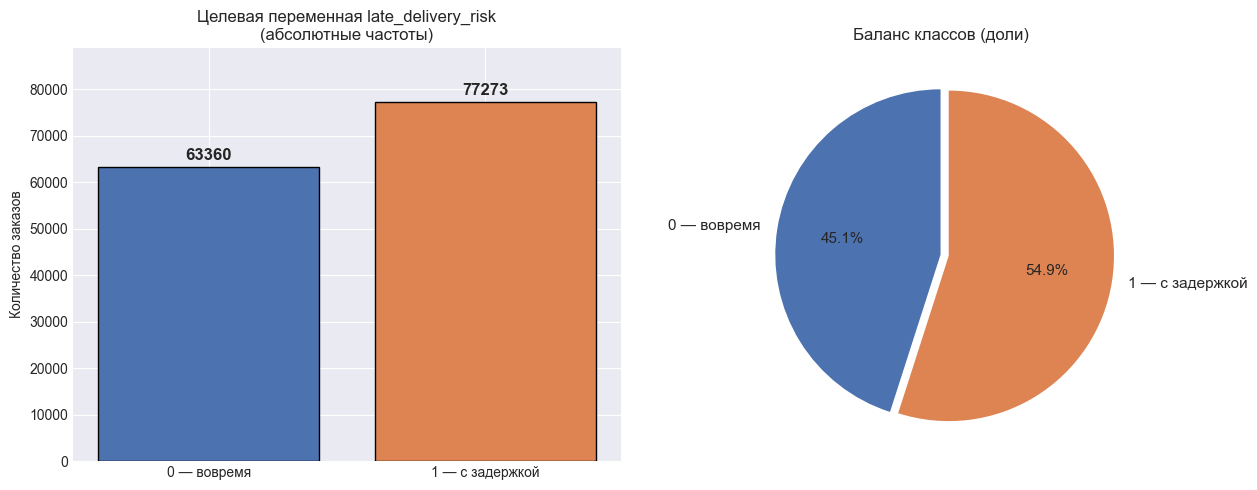

In [19]:
# Рассчитываем количество и доли целевой переменной
class_counts = df_orders['late_delivery_risk'].value_counts().sort_index()
class_share = df_orders['late_delivery_risk'].value_counts(normalize=True).sort_index()

labels = ['0 — вовремя', '1 — с задержкой']
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Строим столбчатую диаграмму количества
bars = axes[0].bar(labels, class_counts.values, color=colors, edgecolor='black')
for bar, share in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f'{share}',
        ha='center', fontsize=12, fontweight='bold'
    )
axes[0].set_title('Целевая переменная late_delivery_risk\n(абсолютные частоты)')
axes[0].set_ylabel('Количество заказов')
axes[0].set_ylim(0, class_counts.max() * 1.15)

# Строим круговую диаграмму долей
axes[1].pie(
    class_share.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.05),
    textprops={'fontsize': 11}
)
axes[1].set_title('Баланс классов (доли)')

plt.tight_layout()
plt.show()

#### Промежуточный итог

1. Доля заказов с задержкой (`late_delivery_risk = 1`) составляет **≈ 54.9%**, вовремя — **≈ 45.1%**. Это подтверждает цифру после внутреннего аудита (55% задержек) и гипотезу о критической ситуации с соблюдением SLA.

2. Дисбаланс классов умеренный (разница ~10 п.п.), выраженного перекоса нет, поэтому специальные техники борьбы с дисбалансом (взвешивание классов, `oversampling`/`undersampling`) на этапе моделирования не требуются.

3. Выбранная метрика `ROC-AUC` устойчива к такому смещению и корректно оценивает способность модели ранжировать заказы по риску, что соответствует бизнес-задаче `CargaPronto`.

### [3.2. Географический аудит](#content)<a id="3_2"></a>

In [20]:
# Создаем функцию для отображения графика с регионами
def plot_regions(df):
    """
    Строит диаграмму рассеяния координат клиентов и выделяет аномалии.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Основное облако точек и аномалии разными цветами
    for status, color in zip(['В регионе (США/Пуэрто-Рико)', 'Аномалия («цифровой шум»)'], ["#27C033", "#9352DD"]):
        subset = df[df['geo_status'] == status]
        ax.scatter(subset['customer_lon'], subset['customer_lat'], alpha=0.5, color=color, label=status)

    # Визуальные границы рабочего региона
    ax.set_xlim(-170, 170)
    ax.set_ylim(-100, 100) 
    ax.axvspan(LON_MIN, LON_MAX, ymin=0.5, ymax=1,
            alpha=0.06, color='green',
            label='Рабочий регион (lon -125…-20, lat ≥ 0)')

    ax.set_xlabel('Долгота (customer_lon)')
    ax.set_ylabel('Широта (customer_lat)')
    ax.set_title('Географический аудит клиентов CargaPronto:\nкоординаты клиентов и «цифровой шум»')
    ax.legend(loc='upper left', fontsize=10)
    
    plt.show()

In [21]:
# Создаем функцию для определения региона
def geo_status(row):
    """
    Определяет регион клиента по его координатам.
    """
    if (LON_MIN <= row['customer_lon'] <= LON_MAX) and (row['customer_lat'] >= LAT_MIN):
        return 'В регионе (США/Пуэрто-Рико)'
    return 'Аномалия («цифровой шум»)'

Распределение точек по зонам:


,geo_status,Количество
0,В регионе (США/Пуэрто-Рико),20480
1,Аномалия («цифровой шум»),156


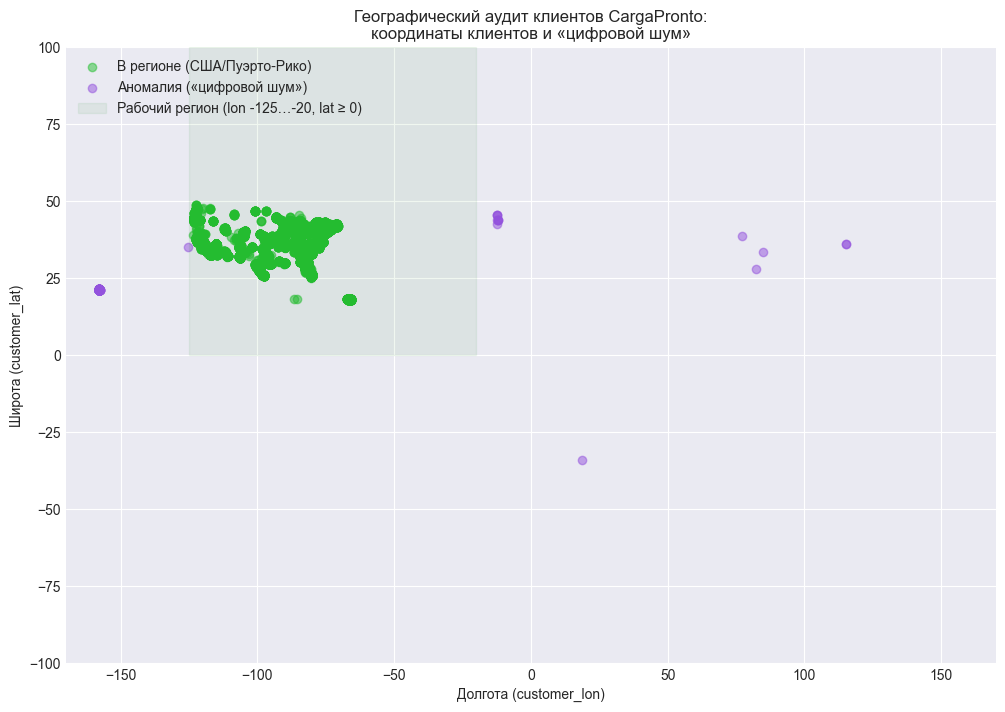

In [22]:
# Создаем новый столбец с информацией о регионе
audit_df = df_customers.copy()
audit_df['geo_status'] = audit_df.apply(geo_status, axis=1)

# Распределение точек по регионам
geo_counts = audit_df['geo_status'].value_counts()
geo_summary = geo_counts.reset_index(name='Количество')

print('Распределение точек по зонам:')
display(geo_summary)

# Выводим график с распределением точек по регионам
plot_regions(audit_df)

#### Промежуточный итог

1. На диаграмме рассеяния координат клиентов основное облако точек сосредоточено в регионе США и Пуэрто-Рико, что соответствует зоне работы CargaPronto.

2. Выявлены аномальные точки («цифровой шум»): **156 клиентов (≈ 0.76% от 20 636)** находятся за пределами рабочего региона — в южном полушарии, в Атлантике и за его пределами (широта до −33.9°, долгота до +115°). Это ошибки GPS или дефолтные значения приборов.

3. Остальные 20 480 клиентов (≈ 99.24%) расположены корректно.

4. Аномальные точки образуют компактные «скопления» отдельно от основного облака — их удаление не затронет корректные данные. Это критически важно, так как K-Means чувствителен к выбросам: даже несколько «улетевших» точек могут сместить центроиды кластеров и разрушить сегментацию.

### [3.3. Удаление аномалий](#content)<a id="3_3"></a>

Распределение точек по зонам:


,geo_status,Количество
0,В регионе (США/Пуэрто-Рико),20480


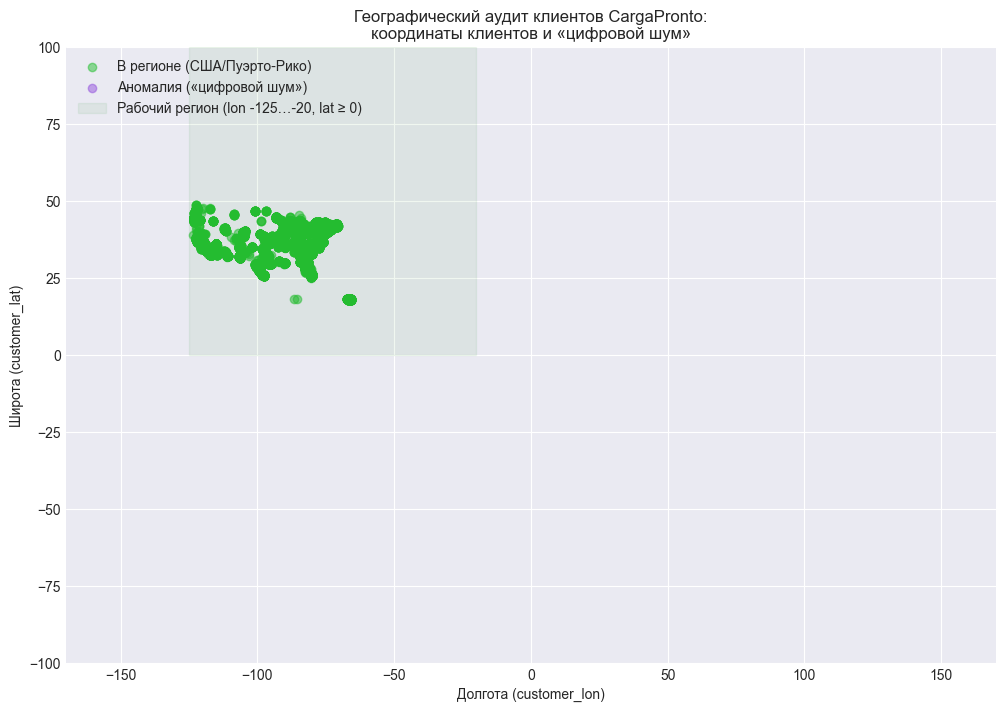

In [23]:
# Удаляем аномалии в регионах
audit_df_clean = audit_df[audit_df['geo_status'] != 'Аномалия («цифровой шум»)']

# Распределение точек по регионам
geo_counts_clean = audit_df_clean['geo_status'].value_counts()
geo_summary_clean = geo_counts_clean.reset_index(name='Количество')

print('Распределение точек по зонам:')
display(geo_summary_clean)

# Выводим график с распределением точек по регионам
plot_regions(audit_df_clean)

In [24]:
# Определяем клиентов, которые являются аномалий
anomaly_ids = audit_df.loc[audit_df['geo_status'] == 'Аномалия («цифровой шум»)', 'customer_id']

# Удаляем аномальные профили из датасетов
df_customers_clean = df_customers[~df_customers['customer_id'].isin(anomaly_ids)]
df_orders_clean = df_orders[~df_orders['customer_id'].isin(anomaly_ids)]

# Выводим размеры датасетов после очистки
print('Итоговый размер df_customers_clean:', df_customers_clean.shape)
print('Итоговый размер df_orders_clean:', df_orders_clean.shape)
print('Заказов без профиля после чистки:', (~df_orders_clean['customer_id'].isin(df_customers_clean['customer_id'])).sum())

# Проверяем баланса классов после очистки
risk_rate = df_orders_clean['late_delivery_risk'].mean()
print(f'Доля задержек после чистки ≈ {risk_rate:.1%}')

Итоговый размер df_customers_clean: (20480, 8)
Итоговый размер df_orders_clean: (139515, 12)
Заказов без профиля после чистки: 0
Доля задержек после чистки ≈ 55.0%


#### Промежуточный итог

1. *Аномалии выявлены:* 156 клиентов (≈ 0.76% от справочника) находятся за пределами рабочего региона CargaPronto (долгота за границами −125…−20 или широта ниже нуля) — это «цифровой шум»: ошибки GPS и дефолтные значения приборов.

2. *Профили-аномалии удалены:* из справочника исключены 156 клиентов, итоговый размер очищенного датасета — 20 480 строк × 8 колонок. Чистка обязательна, поскольку K-Means крайне чувствителен к выбросам: единичные «улетевшие» точки могли бы сместить центроиды логистических зон и разрушить сегментацию.

3. *Целостность сохранена:* из таблицы заказов удалено 1 118 записей, принадлежавших клиентам-аномалиям, — итоговый размер 139 515 строк × 12 колонок. Заказов без профиля после чистки — 0, связи между таблицами не нарушены.

4. *Баланс классов устойчив:* доля задержек после чистки ≈ 55.0% (до чистки — 54.9%), удаление «цифрового шума» не внесло смещения в целевую переменную.

*Вывод:* Географические аномалии полностью исключены из обеих таблиц без нарушения целостности. Очищенные датасеты `df_customers_clean` и `df_orders_clean` готовы к анализу.

### [3.4. Анализ зависимостей между признаками](#content)<a id="3_4"></a>

## [4. Разделение на выборки](#content)<a id="4"></a>

Разделите датафрейм с заказами на выборки. В этом проекте вам предстоит  использовать «классическое» разделение на три выборки: обучающую, валидационную и тестовую. Использовать для этого нужно не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

Ниже приведён пример того, как отделить часть данных для обучения, используя `customer_id` как ключ для группировки.

```python
from sklearn.model_selection import GroupShuffleSplit

# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train = df_orders.iloc[train_idx]
df_test = df_orders.iloc[test_idx]

```


1. Разделите данные из датафрейма с заказами  на три выборки  в соотношении 60:20:20.


2. После разделения обязательно убедитесь, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

## [5. Обучение базовой модели](#content)<a id="5"></a>

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.






### [5.1. Логистическая регрессия](#content)<a id="5_1"></a>

### [5.2. CatBoostClassifier](#content)<a id="5_2"></a>

### [5.3. Оценка качества на валидационной выборке](#content)<a id="5_3"></a>

## [6. Кластеризация по признакам, связанным с местоположением](#content)<a id="6"></a>



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

### [6.1. Подготовка признаков и защита от утечки данных](#content)<a id="6_1"></a>

### [6.2. Выбор числа кластеров методом локтя](#content)<a id="6_2"></a>

### [6.3. Визуализация кластеров и центроидов](#content)<a id="6_3"></a>

## [7. Кластеризация по признакам профилей клиентов](#content)<a id="7"></a>





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



### [7.1. Подготовка векторов признаков и предобработка](#content)<a id="7_1"></a>

### [7.2. Выбор числа кластеров методом локтя](#content)<a id="7_2"></a>

### [7.3. Анализ полученных сегментов](#content)<a id="7_3"></a>

### [7.4. Визуализация кластеров с помощью t-SNE](#content)<a id="7_4"></a>

## [8. Обучение модели на новых признаках](#content)<a id="8"></a>

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

### [8.1. Добавление `geo_cluster` и `beh_cluster` в данные](#content)<a id="8_1"></a>

### [8.2. Обучение финальных моделей](#content)<a id="8_2"></a>

### [8.3. Оценка ROC-AUC на валидационной выборке](#content)<a id="8_3"></a>

## [9. Дополнительное задание — подбор лучшего количества кластеров](#content)<a id="9"></a>

Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```



## [10. Тестирование лучшей модели](#content)<a id="10"></a>

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

### [10.1. Предсказание на тестовой выборке и итоговый ROC-AUC](#content)<a id="10_1"></a>

### [10.2. Матрица ошибок](#content)<a id="10_2"></a>

### [10.3. Анализ важности признаков](#content)<a id="10_3"></a>

## [11. Выводы и рекомендации](#content)<a id="11"></a>

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.